# 1. Command（节点内自决）

In [2]:
from typing import Literal

from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.types import Command
from rich import print

load_dotenv(override=True)

model = init_chat_model(
    model_provider="deepseek",
    model="deepseek-flash",
    extra_body={"thinking": {"type": "disabled"}}
)


# 定义工具
@tool(parse_docstring=True)
def get_weather(city: str) -> str:
    """根据城市名称查询天气

    Args:
        city (str): 城市名称

    Returns:
        str: 城市天气情况
    """
    return f"{city} 的天气是晴天，温度 25°C"


@tool(parse_docstring=True)
def get_news(topic: Literal["科技", "体育", "娱乐"]) -> str:
    """根据主题查询新闻

    Args:
        topic (Literal["科技", "体育", "娱乐"]): 新闻主题

    Returns:
        str: 新闻内容
    """
    return {
        "科技": "最新科技新闻：AI 技术正在快速发展。",
        "体育": "最新体育新闻：中国队取得了胜利。",
        "娱乐": "最新娱乐新闻：歌手发布了新专辑。",
    }[topic]


tools = [get_weather, get_news]
model_with_tools = model.bind_tools(tools)


# 定义状态
class State(MessagesState):
    pass


# llm_node 固定格式：读完整历史 -> 调模型 -> 返回消息增量 -> tool_node / END
def llm_node(state: State) -> Command[Literal["tool_node", END]]:
    ai_msg = model_with_tools.invoke(state["messages"])
    goto = "tool_node" if ai_msg.tool_calls else END
    return Command(goto=goto, update={"messages": [ai_msg]})


# tool_node 固定格式：遍历 tool_calls -> 逐个执行 -> 每个 call 一条 ToolMessage -> llm_node
def tool_node(state: State) -> Command["llm_node"]:
    last = state["messages"][-1]
    tool_map = {t.name: t for t in tools}  # 名字 -> 工具对象
    messages = []

    for tc in last.tool_calls:
        tool_name = tc["name"]
        tool_args = tc["args"]
        tool_id = tc["id"]
        selected = tool_map.get(tool_name)
        if selected:
            result = selected.invoke(tool_args)  # 调用工具函数
        else:
            result = f"未知工具{tool_name}"
        from langchain_core.messages import ToolMessage
        messages.append(ToolMessage(content=str(result), tool_call_id=tool_id))
    return Command(goto="llm_node", update={"messages": messages})


builder = StateGraph(state_schema=State)

builder.add_node("llm_node", llm_node)
builder.add_node("tool_node", tool_node)
builder.add_edge(START, "llm_node")

graph = builder.compile()

res = graph.invoke({"messages": [HumanMessage("帮我查一下北京的天气和科技相关的新闻")]})
print(res)

{
    'messages': [
        HumanMessage(
            content='帮我查一下北京的天气和科技相关的新闻',
            additional_kwargs={},
            response_metadata={},
            id='0a9e8871-5811-4f27-a107-d7df3b054852'
        ),
        AIMessage(
            content="I'll look up both for you right away.",
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 76,
                    'prompt_tokens': 345,
                    'total_tokens': 421,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 128,
                        'image_tokens': None,
                        'text_tokens': None
                    },
                    'prompt_cache_hit_tokens': 128,
                    'prompt_cache_miss_tokens': 217
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-flash',
                'system_fingerprint': 'aeb56401ca74e127821c4f9126dcb669',
                'id': '410b5774-bef9-48de-82fc-627258a1ae9b',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a0b0c1-f1c9-76b1-9dee-9d6d1c4dfbde-0',
            tool_calls=[
                {
                    'name': 'get_weather',
                    'args': {'city': '北京'},
                    'id': 'call_00_PDWsabrAddHxkSMR5M5V1296',
                    'type': 'tool_call'
                },
                {
                    'name': 'get_news',
                    'args': {'topic': '科技'},
                    'id': 'call_01_nVW9HkrZyXf8adedyn7Z2496',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 345,
                'output_tokens': 76,
                'total_tokens': 421,
                'input_token_details': {'cache_read': 128},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='北京 的天气是晴天，温度 25°C',
            id='b775a377-b6b7-456f-84b0-0c3bf8780109',
            tool_call_id='call_00_PDWsabrAddHxkSMR5M5V1296'
        ),
        ToolMessage(
            content='最新科技新闻：AI 技术正在快速发展。',
            id='7a19a0d3-3823-4cde-84aa-4a2a76b30b71',
            tool_call_id='call_01_nVW9HkrZyXf8adedyn7Z2496'
        ),
        AIMessage(
            content='已经帮你查到了两项信息：\n\n**🌤️ 北京天气**\n- 天气：晴天\n- 温度：25°C\n- 
整体舒适宜人，适合外出活动，建议注意防晒。\n\n**📰 科技新闻**\n- 最新动态：AI 
技术正在快速发展。\n\n如果你想了解更具体的内容（比如某个科技公司的新闻、或北京未来几天的天气趋势），告诉我，我再帮
你细查。',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 89,
                    'prompt_tokens': 462,
                    'total_tokens': 551,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 256,
                        'image_tokens': None,
                        'text_tokens': None
                    },
                    'prompt_cache_hit_tokens': 256,
                    'prompt_cache_miss_tokens': 206
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-flash',
                'system_fingerprint': 'aeb56401ca74e127821c4f9126dcb669',
                'id': '0d832e3b-bad4-467c-86b9-5c57b6c4151f',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a0b0c1-f4de-79f3-8612-453a35939109-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
             

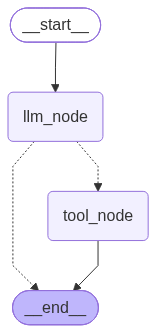

None

In [3]:
from IPython.display import display

print(display(graph))

# 2. router + 条件边

In [5]:
# 动态跳转 : Command [goto, update]
from typing import Literal

from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.types import Command
from rich import print
from langchain_core.messages import ToolMessage

load_dotenv(override=True)

model = init_chat_model(
    model_provider="deepseek",
    model="deepseek-flash",
    extra_body={"thinking": {"type": "disabled"}}
)


# 定义工具
@tool(parse_docstring=True)
def get_weather(city: str) -> str:
    """根据城市名称查询天气

    Args:
        city (str): 城市名称

    Returns:
        str: 城市天气情况
    """
    return f"{city} 的天气是晴天，温度 25°C"


@tool(parse_docstring=True)
def get_news(topic: Literal["科技", "体育", "娱乐"]) -> str:
    """根据主题查询新闻

    Args:
        topic (Literal["科技", "体育", "娱乐"]): 新闻主题

    Returns:
        str: 新闻内容
    """
    return {
        "科技": "最新科技新闻：AI 技术正在快速发展。",
        "体育": "最新体育新闻：中国队取得了胜利。",
        "娱乐": "最新娱乐新闻：歌手发布了新专辑。",
    }[topic]


tools = [get_weather, get_news]
model_with_tools = model.bind_tools(tools)


# 定义状态
class State(MessagesState):
    pass


# 模型节点
def llm_node(state: State) -> State:
    ai_msg = model_with_tools.invoke(state["messages"])
    return {"messages": [ai_msg]}


# 工具节点
def tool_node(state: State) -> State:
    last = state["messages"][-1]
    tool_map = {t.name: t for t in tools}
    messages = []
    for tc in last.tool_calls:
        selected = tool_map.get(tc["name"])
        if selected:
            res = selected.invoke(tc['args'])
        else:
            res = f"未知工具: {tc['name']}"

        messages.append(ToolMessage(content=res, tool_call_id=tc["id"]))

    return {"messages": messages}


def router(state: State) -> Literal["tool_node", END]:
    # 判断本轮模型输出：有 tool_calls 去工具节点，没有就结束
    return "tool_node" if state["messages"][-1].tool_calls else END


builder = StateGraph(state_schema=State)
builder.add_node("llm_node", llm_node)
builder.add_node("tool_node", tool_node)
builder.add_edge(START, "llm_node")
builder.add_conditional_edges("llm_node", router, [END, "tool_node"])  # 动态跳转
builder.add_edge("tool_node", "llm_node")  # 固定回环

graph = builder.compile()
res = graph.invoke({"messages": [HumanMessage("帮我查一下北京的天气和科技相关的新闻")]})
print(res)

{
    'messages': [
        HumanMessage(
            content='帮我查一下北京的天气和科技相关的新闻',
            additional_kwargs={},
            response_metadata={},
            id='2fe3b5fa-4074-462a-a5db-096e8af174b9'
        ),
        AIMessage(
            content='我来帮您查询北京的天气和科技新闻。',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 76,
                    'prompt_tokens': 345,
                    'total_tokens': 421,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 128,
                        'image_tokens': None,
                        'text_tokens': None
                    },
                    'prompt_cache_hit_tokens': 128,
                    'prompt_cache_miss_tokens': 217
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-flash',
                'system_fingerprint': 'aeb56401ca74e127821c4f9126dcb669',
                'id': '1d870707-01f2-4694-9f32-7dfe8970a60e',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a0b0c2-2622-7cd2-afa2-05d4e7783cf7-0',
            tool_calls=[
                {
                    'name': 'get_weather',
                    'args': {'city': '北京'},
                    'id': 'call_00_6WJzSj0ZS3GJQSiUr0MC5849',
                    'type': 'tool_call'
                },
                {
                    'name': 'get_news',
                    'args': {'topic': '科技'},
                    'id': 'call_01_UEdRruG0CG8bQVJmPWlI9018',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 345,
                'output_tokens': 76,
                'total_tokens': 421,
                'input_token_details': {'cache_read': 128},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='北京 的天气是晴天，温度 25°C',
            id='23de6800-fc73-4a38-9086-d842758693e3',
            tool_call_id='call_00_6WJzSj0ZS3GJQSiUr0MC5849'
        ),
        ToolMessage(
            content='最新科技新闻：AI 技术正在快速发展。',
            id='bc33c5eb-3710-4ebd-a334-51b1a6072272',
            tool_call_id='call_01_UEdRruG0CG8bQVJmPWlI9018'
        ),
        AIMessage(
            content='已经帮您查到啦，以下是结果：\n\n**🌤️ 北京天气**\n- 天气：晴天\n- 温度：25°C\n\n**📱 
科技新闻**\n- 最新科技新闻：AI 技术正在快速发展。\n\n北京今天天气晴朗、气温舒适（25°C），适合外出活动。科技方面，AI
技术正处于快速发展阶段，是当前的热点话题。如需了解更多细节或其他城市、主题的信息，随时告诉我！',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 94,
                    'prompt_tokens': 462,
                    'total_tokens': 556,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 256,
                        'image_tokens': None,
                        'text_tokens': None
                    },
                    'prompt_cache_hit_tokens': 256,
                    'prompt_cache_miss_tokens': 206
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-flash',
                'system_fingerprint': 'aeb56401ca74e127821c4f9126dcb669',
                'id': '187b37b5-f7c4-4eb4-8bf9-da13d3c44f0b',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a0b0c2-28f4-7421-a650-06b57c1a93b3-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_t

In [ ]:
from IPython.display import display

print(display(graph))